# Penanganan Missing Value Konsentrasi 4 Polutan (CH4, CO, NO2, SO2) Menggunakan Metode Interpolasi Polinomial

**Dataset Input**: `data/csv/pertemuan-5-csv/clean outlier/polutan_4_clean_iqr.csv` (Data 365 Hari Bebas Outlier)  
**Tujuan**: Menangani dan menambal seluruh nilai yang hilang (*missing values* asli dan bekas pencilan yang di-NaN-kan) pada 4 polutan udara (`CH4`, `CO`, `NO2`, `SO2`) secara bertahap menggunakan metode **Interpolasi Polinomial Orde 2 (Kuadratik)**. Proses ini menghasilkan dataset deret waktu tahunan yang bersih sempurna (*final clean dataset*) sepanjang 365 hari lengkap (0 NaN) yang disimpan ke folder `data/csv/pertemuan-5-csv/data bersih/` sebagai input siap pakai untuk tahapan ekstraksi fitur TSFEL.

## Tahap 1: Memuat Data Bebas Outlier dan Eksplorasi Profil Missing Values 4 Polutan

=== PROFIL DATASET BEBAS OUTLIER 4 POLUTAN (HARI 1 - 365) ===
Total Baris Data        : 365 hari
Rentang Tanggal         : 2025-08-24 s.d. 2026-08-23


,Polutan,Total Hari,Data Valid (Hari),Persentase Valid,Missing Values (Hari),Persentase Missing
0,CH4,365,17,4.66%,348,95.34%
1,CO,365,212,58.08%,153,41.92%
2,NO2,365,181,49.59%,184,50.41%
3,SO2,365,218,59.73%,147,40.27%


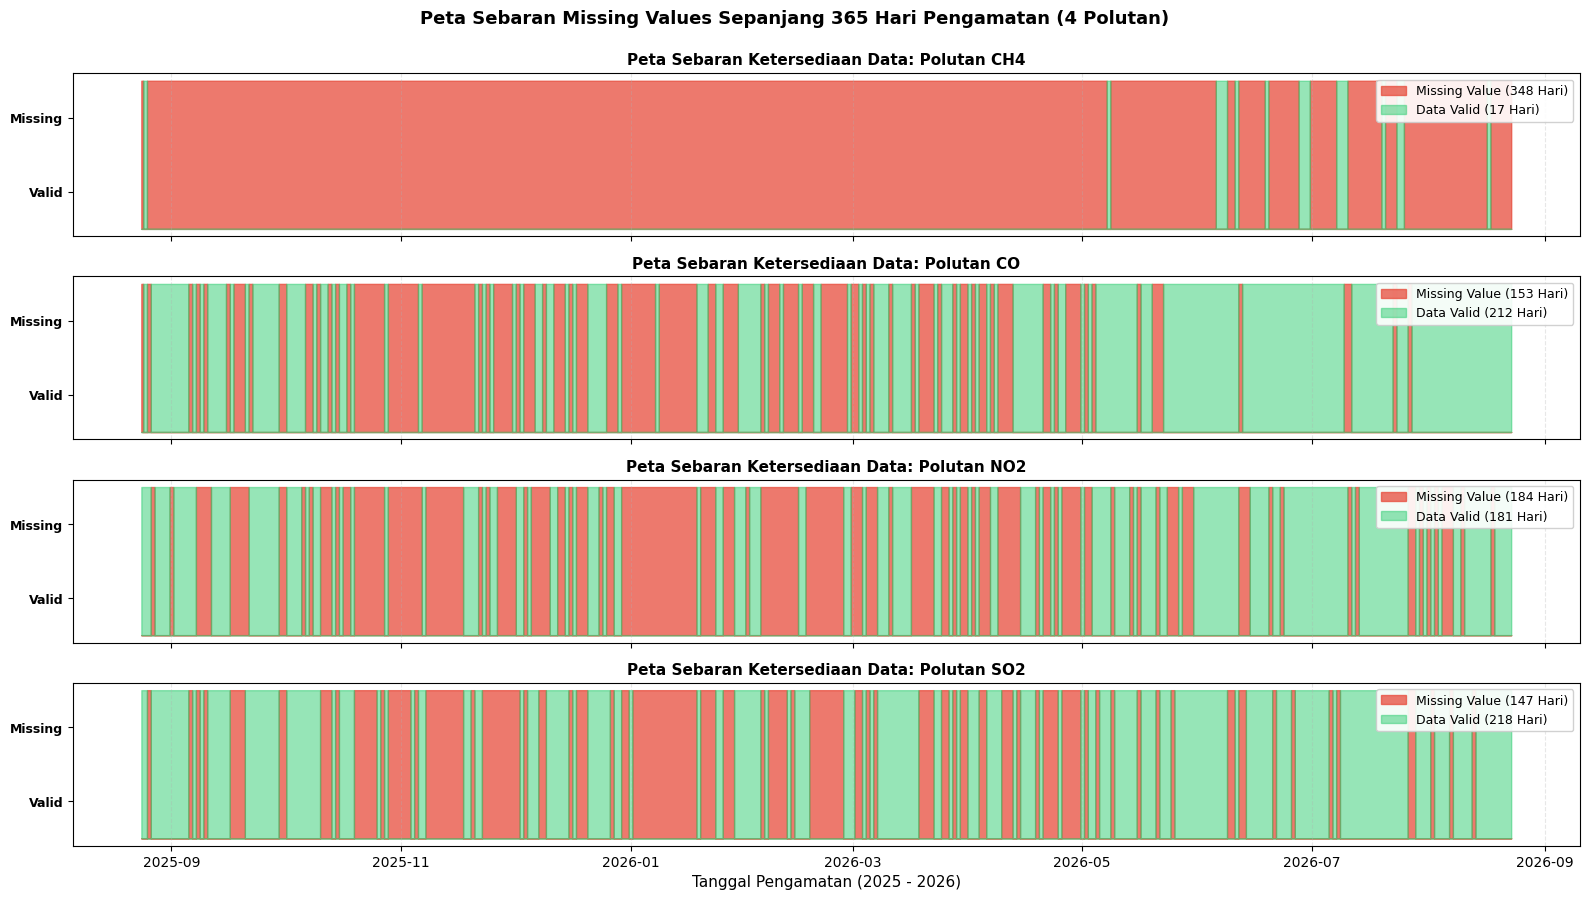

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Pemuatan dataset bersih bebas outlier dari tahap deteksi outlier IQR
input_path = "../data/csv/pertemuan-5-csv/clean outlier/polutan_4_clean_iqr.csv"
if not os.path.exists(input_path):
    input_path = "data/csv/pertemuan-5-csv/clean outlier/polutan_4_clean_iqr.csv"

df = pd.read_csv(input_path)
df['tanggal'] = pd.to_datetime(df['tanggal'])
pollutants = ['CH4', 'CO', 'NO2', 'SO2']

# 2. Profil ketersediaan data dan missing value 4 polutan
profil_list = []
for p in pollutants:
    n_valid = df[p].notna().sum()
    n_missing = df[p].isna().sum()
    pct_valid = (n_valid / len(df)) * 100
    pct_missing = (n_missing / len(df)) * 100
    profil_list.append({
        'Polutan': p,
        'Total Hari': len(df),
        'Data Valid (Hari)': n_valid,
        'Persentase Valid': f"{pct_valid:.2f}%",
        'Missing Values (Hari)': n_missing,
        'Persentase Missing': f"{pct_missing:.2f}%"
    })

df_profil = pd.DataFrame(profil_list)

print("=== PROFIL DATASET BEBAS OUTLIER 4 POLUTAN (HARI 1 - 365) ===")
print(f"Total Baris Data        : {len(df)} hari")
print(f"Rentang Tanggal         : {df['tanggal'].min().strftime('%Y-%m-%d')} s.d. {df['tanggal'].max().strftime('%Y-%m-%d')}")
display(df_profil)

# 3. Visualisasi Peta Sebaran Missing Value 4 Polutan
fig, axes = plt.subplots(4, 1, figsize=(16, 9), sharex=True)
colors = {'CH4': '#1f77b4', 'CO': '#ff7f0e', 'NO2': '#2ca02c', 'SO2': '#9467bd'}

for i, p in enumerate(pollutants):
    ax = axes[i]
    mask = df[p].isna().astype(int)
    n_miss = df[p].isna().sum()
    n_val = df[p].notna().sum()
    
    ax.fill_between(df['tanggal'], 0, mask, color='#e74c3c', alpha=0.75, step='mid', label=f'Missing Value ({n_miss} Hari)')
    ax.fill_between(df['tanggal'], 0, 1 - mask, color='#2ecc71', alpha=0.5, step='mid', label=f'Data Valid ({n_val} Hari)')
    ax.set_yticks([0.25, 0.75])
    ax.set_yticklabels(['Valid', 'Missing'], fontsize=9, fontweight='bold')
    ax.set_title(f'Peta Sebaran Ketersediaan Data: Polutan {p}', fontsize=11, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.3, axis='x')
    ax.legend(loc='upper right', framealpha=0.9, fontsize=9)

axes[-1].set_xlabel('Tanggal Pengamatan (2025 - 2026)', fontsize=11)
plt.suptitle('Peta Sebaran Missing Values Sepanjang 365 Hari Pengamatan (4 Polutan)', fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## Tahap 2: Konsep & Rumus Matematis Interpolasi Polinomial

Dalam analisis deret waktu (*time series*), fenomena dispersi dan dinamika polutan di atmosfer bersifat non-linear. Interpolasi polinomial menghubungkan titik-titik data pengamatan menggunakan fungsi kurva kontinu bertingkat (*polynomial curve*).

### 1. Formula Matematis Polinomial Orde-2 (Kuadratik):
Untuk mengisi nilai pada titik waktu $x$, polinomial orde-2 mengestimasi fungsi kuadrat:
$$P_2(x) = a x^2 + b x + c$$

Dengan koefisien $a, b, c$ yang ditentukan berdasarkan titik-titik observasi terdekat.

### 2. Keunggulan Interpolasi Polinomial:
* **Menghasilkan Kurva Mulus (*Smooth Curve*)**: Tidak patah-patah seperti interpolasi linear, lebih mencerminkan fluktuasi alami polutan.
* **Mencegah Distorsi Tangga (*Step Effect*)**: Menghindari lompatan nilai diskret seperti yang terjadi pada metode *forward fill*.
* **Penanganan Titik Ujung (*Boundary Fill*)**: Untuk celah di batas paling awal atau batas akhir rentang pengamatan, diterapkan kombinasi `bfill()` dan `ffill()` untuk memastikan integritas 100% data terisi (0 NaN).

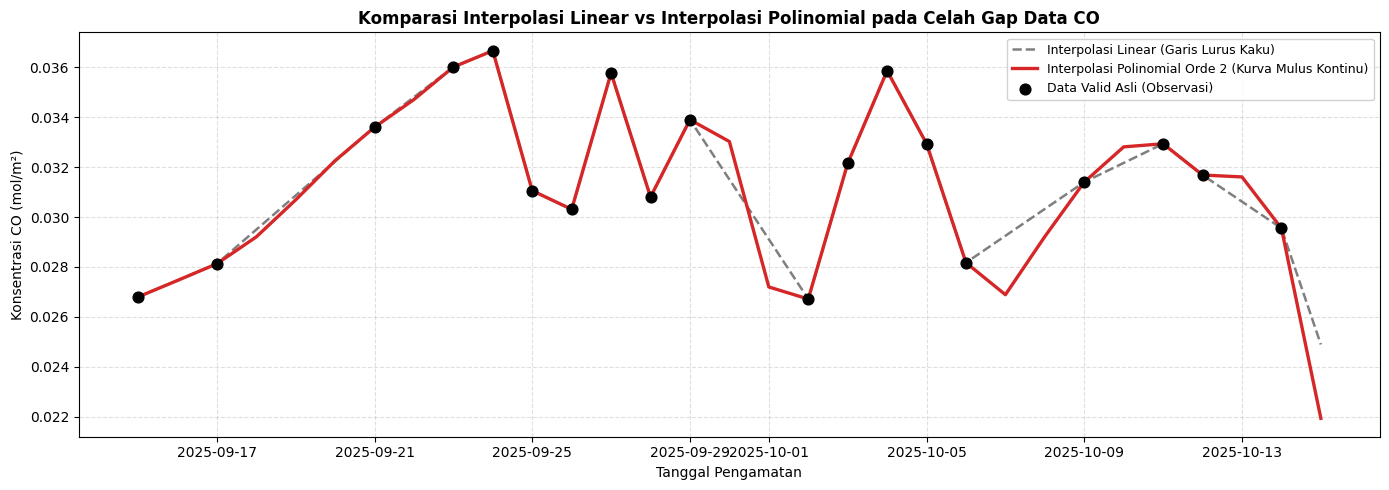

In [2]:
# Komparasi Karakteristik Interpolasi Polinomial vs Metode Lain pada Sampel Gap Data CO
df_comp = df.copy()
df_comp['CO_linear'] = df_comp['CO'].interpolate(method='linear')
df_comp['CO_poly'] = df_comp['CO'].interpolate(method='polynomial', order=2).bfill().ffill()

zoom_mask = (df_comp['tanggal'] >= '2025-09-15') & (df_comp['tanggal'] <= '2025-10-15')
df_z = df_comp[zoom_mask]

plt.figure(figsize=(14, 5))
plt.plot(df_z['tanggal'], df_z['CO_linear'], label='Interpolasi Linear (Garis Lurus Kaku)', linestyle='--', color='#7f7f7f', linewidth=1.8)
plt.plot(df_z['tanggal'], df_z['CO_poly'], label='Interpolasi Polinomial Orde 2 (Kurva Mulus Kontinu)', color='#d62728', linewidth=2.4)
plt.scatter(df_z.dropna(subset=['CO'])['tanggal'], df_z.dropna(subset=['CO'])['CO'], color='black', s=60, zorder=5, label='Data Valid Asli (Observasi)')
plt.title('Komparasi Interpolasi Linear vs Interpolasi Polinomial pada Celah Gap Data CO', fontsize=12, fontweight='bold')
plt.xlabel('Tanggal Pengamatan', fontsize=10)
plt.ylabel('Konsentrasi CO (mol/m²)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(framealpha=0.9, fontsize=9)
plt.tight_layout()
plt.show()

## Tahap 3: Penerapan Interpolasi Polinomial Secara Bertahap untuk 4 Polutan

Penerapan interpolasi polinomial dilakukan secara bertahap pada masing-masing polutan (`CH4`, `CO`, `NO2`, `SO2`) dengan orde kuadratik ($order=2$) diikuti penanganan batas (*boundary fill*) sehingga seluruh 365 baris data terisi lengkap 100% tanpa missing value.

In [3]:
df_imputed = df.copy()

rekap_imputasi = []

for p in pollutants:
    # 1. Catat posisi nilai yang hilang
    is_miss = df[p].isna()
    df_imputed[f'{p}_is_imputed'] = is_miss
    
    # 2. Penerapan Interpolasi Polinomial (Orde 2) + boundary fill (bfill & ffill)
    df_imputed[p] = df[p].interpolate(method='polynomial', order=2).bfill().ffill()
    
    n_asli = (~is_miss).sum()
    n_tambal = is_miss.sum()
    sisa_nan = df_imputed[p].isna().sum()
    
    rekap_imputasi.append({
        'Polutan': p,
        'Total Hari': len(df_imputed),
        'Data Asli Valid': n_asli,
        'Data Ditambal (Polinomial)': n_tambal,
        'Persentase Ditambal': f"{(n_tambal / len(df_imputed) * 100):.2f}%",
        'Sisa Missing (NaN)': sisa_nan,
        'Status': '100% LENGKAP ✓' if sisa_nan == 0 else 'ADA SISA NaN ✗'
    })

df_rekap_imp = pd.DataFrame(rekap_imputasi)
print("=" * 85)
print("HASIL PENERAPAN INTERPOLASI POLINOMIAL PADA 4 POLUTAN (365 HARI LENGKAP)")
print("=" * 85)
display(df_rekap_imp)

print("\n--- 10 Baris Pertama Data Hasil Penambalan Polinomial ---")
display(df_imputed[['tanggal'] + pollutants].head(10))

HASIL PENERAPAN INTERPOLASI POLINOMIAL PADA 4 POLUTAN (365 HARI LENGKAP)


,Polutan,Total Hari,Data Asli Valid,Data Ditambal (Polinomial),Persentase Ditambal,Sisa Missing (NaN),Status
0,CH4,365,17,348,95.34%,0,100% LENGKAP ✓
1,CO,365,212,153,41.92%,0,100% LENGKAP ✓
2,NO2,365,181,184,50.41%,0,100% LENGKAP ✓
3,SO2,365,218,147,40.27%,0,100% LENGKAP ✓



--- 10 Baris Pertama Data Hasil Penambalan Polinomial ---


,tanggal,CH4,CO,NO2,SO2
0,2025-08-24,1867.289429,0.029300,2.940000e-05,0.000346
1,2025-08-25,1867.289429,0.029300,3.970000e-05,0.000038
2,2025-08-26,1852.063505,0.030766,4.000000e-05,-0.000021
3,2025-08-27,1836.956638,0.028946,3.526765e-05,-0.000084
4,2025-08-28,1821.968826,0.025137,3.230000e-05,-0.000198
5,2025-08-29,1807.100071,0.026096,3.170000e-05,0.000496
6,2025-08-30,1792.350371,0.027131,7.130000e-06,0.000188
7,2025-08-31,1777.719728,0.027910,-9.630000e-06,-0.000150
8,2025-09-01,1763.208141,0.026407,-7.795066e-07,-0.000081
9,2025-09-02,1748.815610,0.022154,7.810000e-06,0.000039


## Tahap 4: Visualisasi Hasil Imputasi Polinomial (4 Polutan)

Visualisasi menyeluruh sepanjang 365 hari deret waktu yang membedakan secara tegas antara data asli valid (titik observasi) dan data hasil penambalan interpolasi polinomial (kurva kontinu dan titik imputasi).

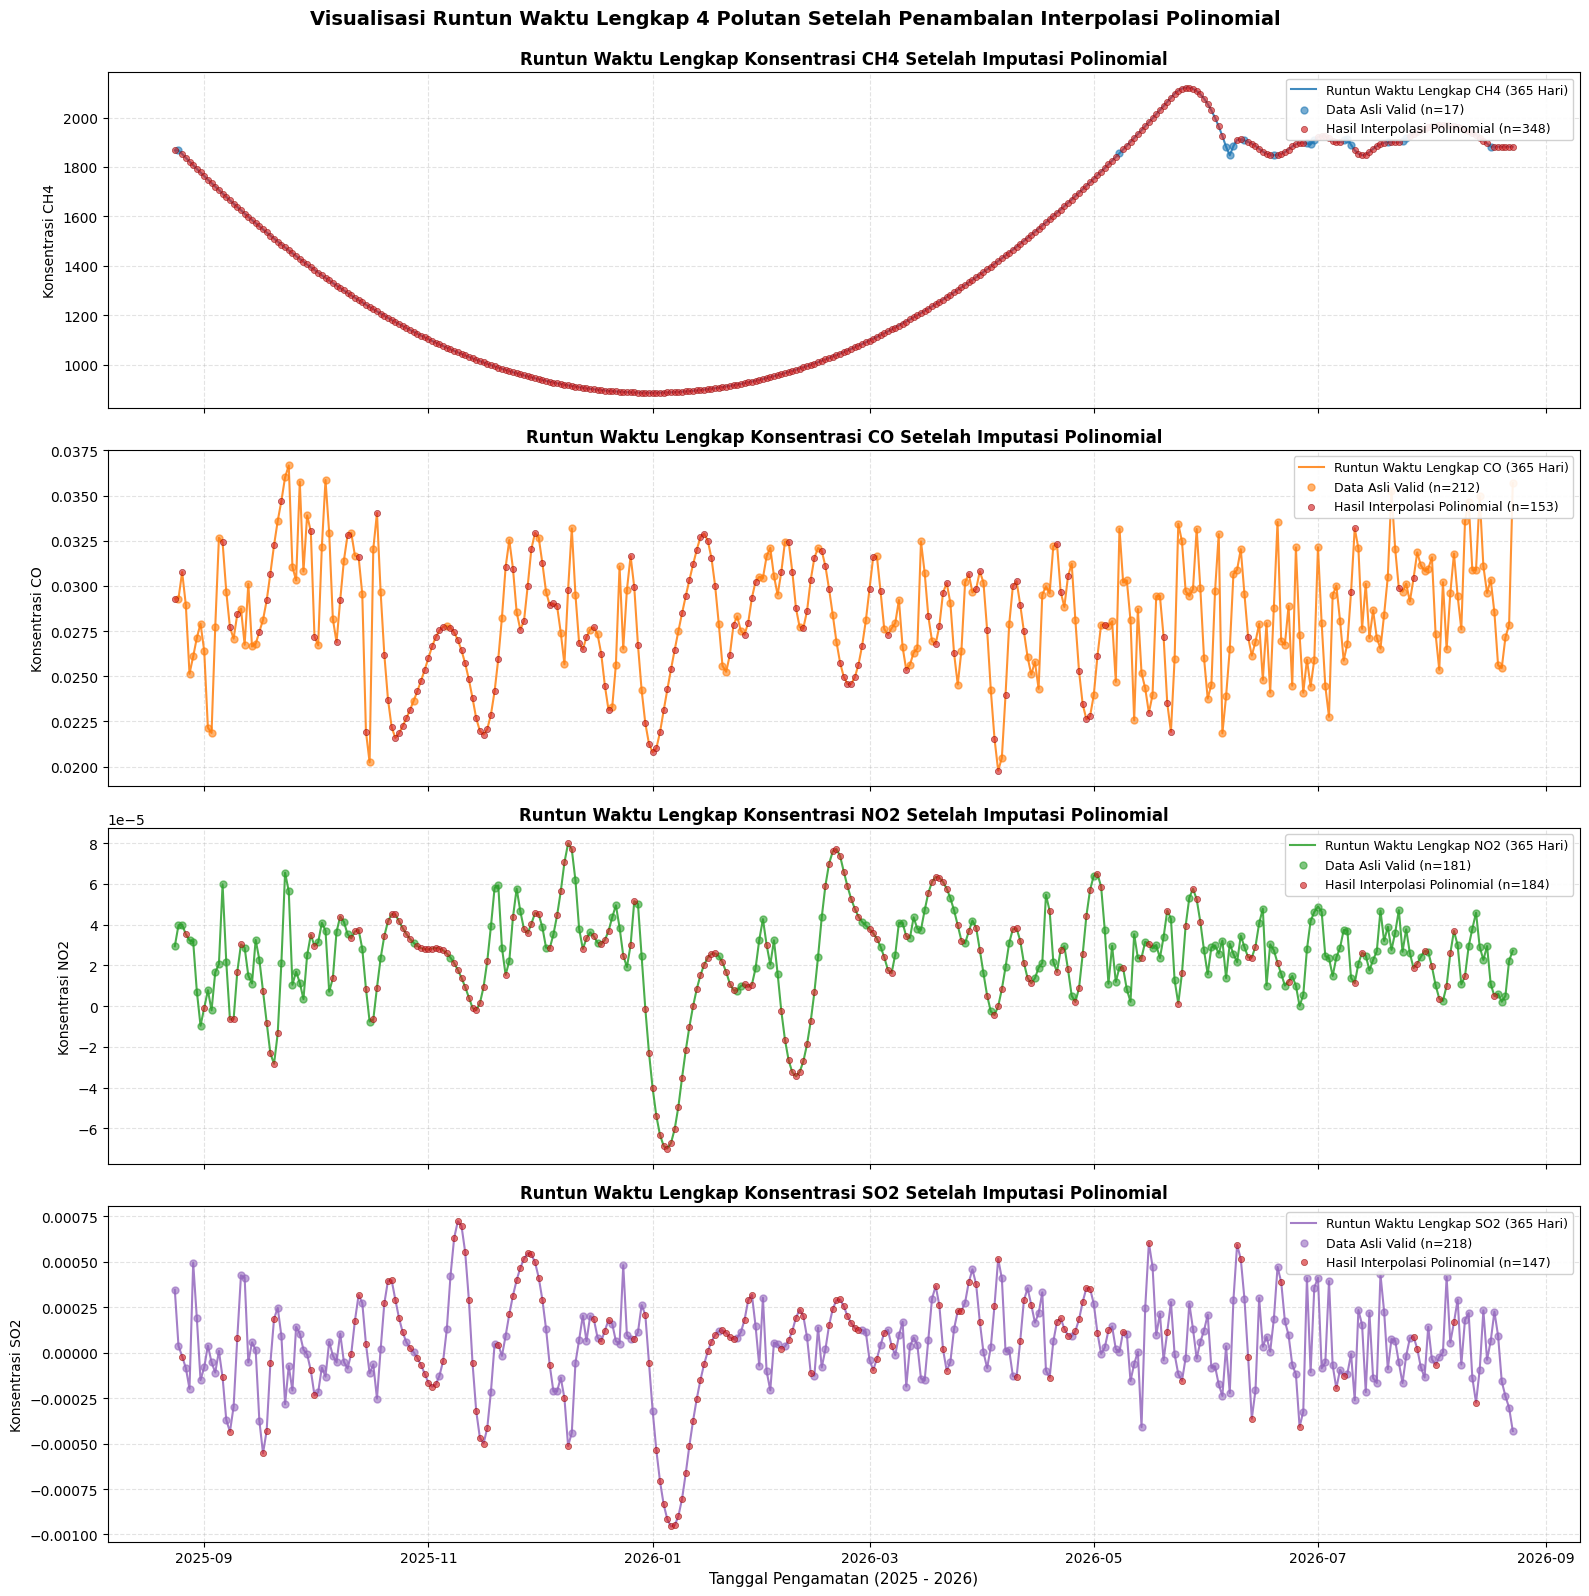

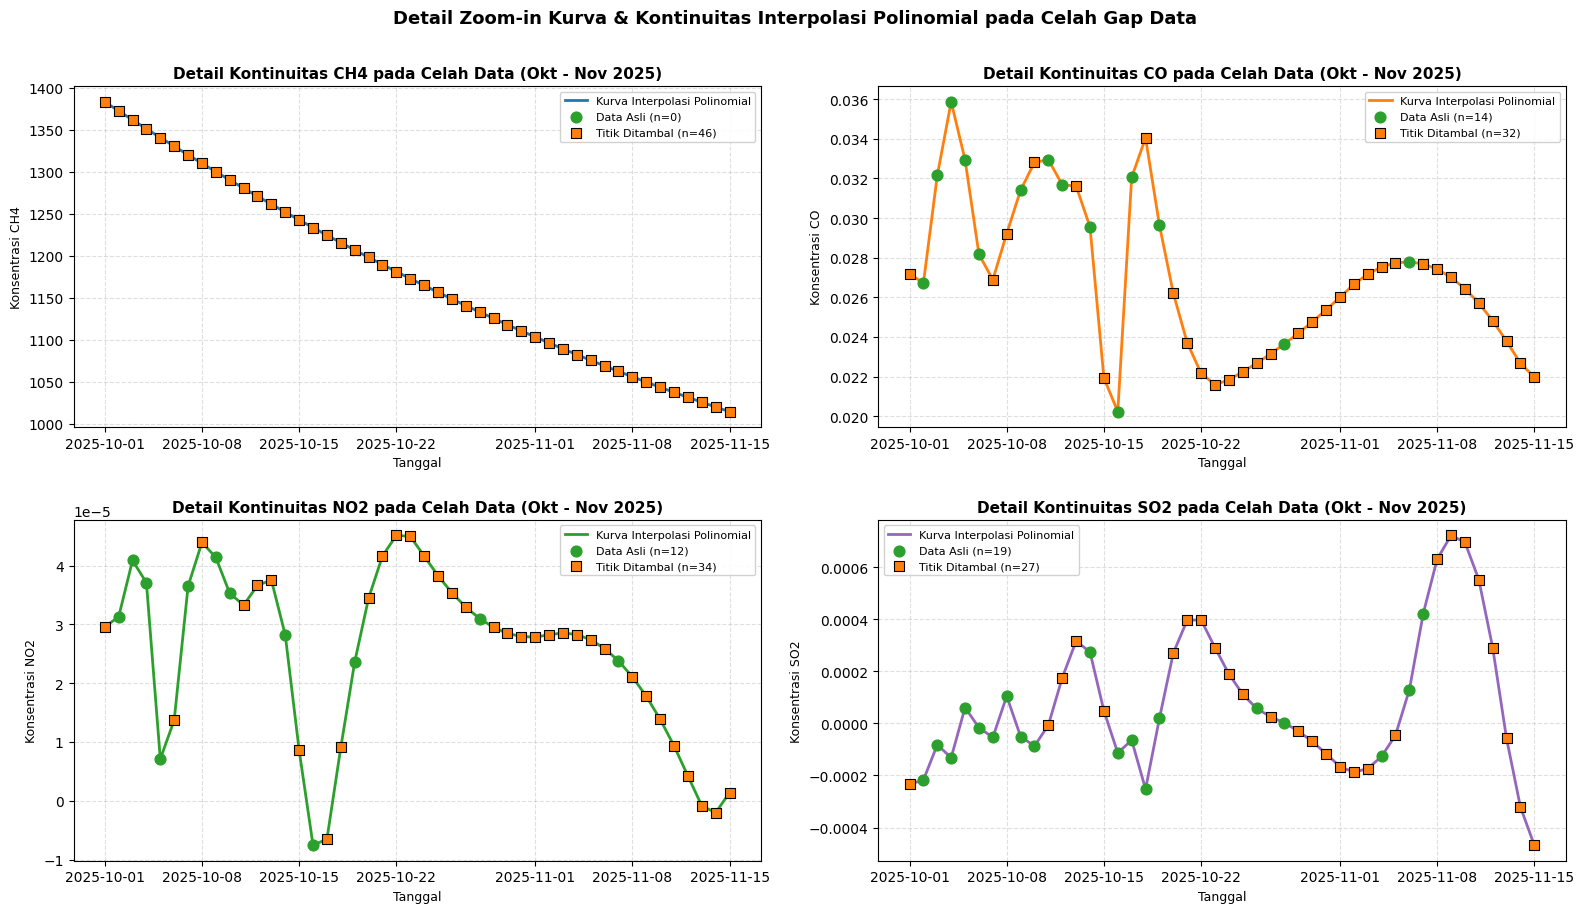

In [4]:
# 1. Visualisasi Full Time Series 365 Hari Hasil Imputasi Polinomial (4 Polutan)
fig, axes = plt.subplots(4, 1, figsize=(16, 16), sharex=True)

for i, p in enumerate(pollutants):
    ax = axes[i]
    is_miss = df_imputed[f'{p}_is_imputed']
    
    # Garis kontinu hasil interpolasi polinomial
    ax.plot(df_imputed['tanggal'], df_imputed[p], color=colors[p], linewidth=1.5, alpha=0.85, label=f'Runtun Waktu Lengkap {p} (365 Hari)')
    
    # Scatter data asli
    ax.scatter(df_imputed.loc[~is_miss, 'tanggal'], df_imputed.loc[~is_miss, p],
               color=colors[p], s=25, alpha=0.6, label=f'Data Asli Valid (n={(~is_miss).sum()})')
    
    # Scatter data hasil penambalan (interpolasi polinomial)
    ax.scatter(df_imputed.loc[is_miss, 'tanggal'], df_imputed.loc[is_miss, p],
               color='#d62728', marker='o', s=20, alpha=0.65, edgecolor='darkred', linewidth=0.5, zorder=4,
               label=f'Hasil Interpolasi Polinomial (n={is_miss.sum()})')
    
    ax.set_title(f'Runtun Waktu Lengkap Konsentrasi {p} Setelah Imputasi Polinomial', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'Konsentrasi {p}', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.35)
    ax.legend(loc='upper right', framealpha=0.9, fontsize=9)

axes[-1].set_xlabel('Tanggal Pengamatan (2025 - 2026)', fontsize=11)
plt.suptitle('Visualisasi Runtun Waktu Lengkap 4 Polutan Setelah Penambalan Interpolasi Polinomial', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# 2. Visualisasi Detail Zoom-in Kontinuitas Interpolasi pada Celah Data (Okt - Nov 2025)
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

zoom_range = (df_imputed['tanggal'] >= '2025-10-01') & (df_imputed['tanggal'] <= '2025-11-15')
df_zoom = df_imputed[zoom_range]

for i, p in enumerate(pollutants):
    ax = axes[i]
    z_miss = df_zoom[f'{p}_is_imputed']
    
    ax.plot(df_zoom['tanggal'], df_zoom[p], color=colors[p], linewidth=2.0, label='Kurva Interpolasi Polinomial')
    ax.scatter(df_zoom.loc[~z_miss, 'tanggal'], df_zoom.loc[~z_miss, p],
               color='#2ca02c', s=60, zorder=5, label=f'Data Asli (n={(~z_miss).sum()})')
    ax.scatter(df_zoom.loc[z_miss, 'tanggal'], df_zoom.loc[z_miss, p],
               color='#ff7f0e', marker='s', s=55, edgecolor='black', linewidth=0.8, zorder=5,
               label=f'Titik Ditambal (n={z_miss.sum()})')
    
    ax.set_title(f'Detail Kontinuitas {p} pada Celah Data (Okt - Nov 2025)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Tanggal', fontsize=9)
    ax.set_ylabel(f'Konsentrasi {p}', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='best', framealpha=0.9, fontsize=8)

plt.suptitle('Detail Zoom-in Kurva & Kontinuitas Interpolasi Polinomial pada Celah Gap Data', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Tahap 5: Ekspor Data Bersih ke Folder 'data bersih'

Menyimpan dataset akhir 4 polutan yang telah 100% bebas dari missing value dan bebas outlier ke satu berkas tunggal `polutan_4_clean.csv` di dalam folder `data/csv/pertemuan-5-csv/data bersih/`. Berkas ini merupakan input siap pakai (*ready-to-use*) untuk tahapan ekstraksi fitur TSFEL berikutnya.

In [5]:
# 1. Penyusunan DataFrame Final Bersih Sempurna
output_folder = "../data/csv/pertemuan-5-csv/data bersih"
if not os.path.exists(output_folder) and not os.path.exists("../data/csv/pertemuan-5-csv"):
    output_folder = "data/csv/pertemuan-5-csv/data bersih"
os.makedirs(output_folder, exist_ok=True)

df_final = pd.DataFrame({
    'tanggal': df_imputed['tanggal'].dt.strftime('%Y-%m-%d'),
    'CH4': df_imputed['CH4'],
    'CO': df_imputed['CO'],
    'NO2': df_imputed['NO2'],
    'SO2': df_imputed['SO2']
})

# Simpan berkas tunggal data bersih
clean_csv_path = os.path.join(output_folder, "polutan_4_clean.csv")
df_final.to_csv(clean_csv_path, index=False)
print(f"✓ Berkas data bersih berhasil disimpan di:\n  {clean_csv_path}")

# 2. Verifikasi Integritas dan Statistik Akhir Dataset
print("\n" + "=" * 90)
print("VERIFIKASI AKHIR DATASET 4 POLUTAN LENGKAP (365 HARI - 0 NaN)")
print("=" * 90)

df_check = pd.read_csv(clean_csv_path)
print(f"Total Baris Data        : {len(df_check)} baris (Tepat 365 hari lengkap)")
print(f"Rentang Waktu           : {df_check['tanggal'].min()} s.d. {df_check['tanggal'].max()}")
print(f"Total Missing Values    : {df_check.isna().sum().sum()} baris (0 NaN di semua kolom)")

stat_final = []
for p in pollutants:
    s = df_check[p]
    stat_final.append({
        'Polutan': p,
        'Jumlah Baris': len(s),
        'Missing Values': s.isna().sum(),
        'Nilai Min': f"{s.min():.6e}",
        'Rata-rata (μ)': f"{s.mean():.6e}",
        'Nilai Max': f"{s.max():.6e}",
        'Std Dev (σ)': f"{s.std():.6e}"
    })

df_stat_final = pd.DataFrame(stat_final)
display(df_stat_final)

print("\n--- 5 Baris Pertama Dataset Bersih ---")
display(df_check.head())
print("\n--- 5 Baris Terakhir Dataset Bersih ---")
display(df_check.tail())

✓ Berkas data bersih berhasil disimpan di:
  ../data/csv/pertemuan-5-csv/data bersih\polutan_4_clean.csv

VERIFIKASI AKHIR DATASET 4 POLUTAN LENGKAP (365 HARI - 0 NaN)
Total Baris Data        : 365 baris (Tepat 365 hari lengkap)
Rentang Waktu           : 2025-08-24 s.d. 2026-08-23
Total Missing Values    : 0 baris (0 NaN di semua kolom)


,Polutan,Jumlah Baris,Missing Values,Nilai Min,Rata-rata (μ),Nilai Max,Std Dev (σ)
0,CH4,365,0,8.860591e+02,1.426631e+03,2.121145e+03,4.127291e+02
1,CO,365,0,1.977544e-02,2.816087e-02,3.666410e-02,3.293758e-03
2,NO2,365,0,-6.995195e-05,2.452045e-05,7.990846e-05,2.343120e-05
3,SO2,365,0,-9.558089e-04,4.014397e-05,7.231513e-04,2.608136e-04



--- 5 Baris Pertama Dataset Bersih ---


,tanggal,CH4,CO,NO2,SO2
0,2025-08-24,1867.289429,0.029300,0.000029,0.000346
1,2025-08-25,1867.289429,0.029300,0.000040,0.000038
2,2025-08-26,1852.063505,0.030766,0.000040,-0.000021
3,2025-08-27,1836.956638,0.028946,0.000035,-0.000084
4,2025-08-28,1821.968826,0.025137,0.000032,-0.000198



--- 5 Baris Terakhir Dataset Bersih ---


,tanggal,CH4,CO,NO2,SO2
360,2026-08-19,1881.842773,0.025605,0.000006,0.000093
361,2026-08-20,1881.842773,0.025459,0.000002,-0.000158
362,2026-08-21,1881.842773,0.027151,0.000005,-0.000239
363,2026-08-22,1881.842773,0.027845,0.000022,-0.000303
364,2026-08-23,1881.842773,0.035688,0.000027,-0.000431
